# Homework 7 Template

Rixin Li & G . Besla



In [ ]:
 # Make edits where instructed - look for "****", which indicates where you need to add code. 

In [3]:
# import necessary modules
# numpy provides powerful multi-dimensional arrays to hold and manipulate data
import numpy as np
# matplotlib provides powerful functions for plotting figures
import matplotlib.pyplot as plt
# astropy provides unit system and constants for astronomical calculations
import astropy.units as u
import astropy.constants as const
# import Latex module so we can display the results with symbols
from IPython.display import Latex
%matplotlib inline

from CenterOfMass import CenterOfMass #to determine the COM pos/vel of M33


from GalaxyMass import ComponentMass #to determine the mass of M31 for each component

# M33AnalyticOrbit

In [7]:
class M33AnalyticOrbit:
    """ Calculate the analytical orbit of M33 around M31 """
    
    def __init__(self, OutputFile): # **** add inputs
        """
        Inputs:
            - OutputFile (string): Filename to save data for analytic orbit (.txt file)
        """

        ### get the gravitational constant (the value is 4.498502151575286e-06)
        self.G = const.G.to(u.kpc**3/u.Msun/u.Gyr**2).value
        
        ### **** store the output file name
        self.filename = OutputFile
        
        ### get the current pos/vel of M33 
        # **** create an instance of the  CenterOfMass class for M33 
        # Simulation files are stored in directory called SimFiles above my Github directory
        M33COM = CenterOfMass('../../../SimFiles/M33/M33_000.txt', 2)

        # **** store the position VECTOR of the M33 COM 
        M33COM_P = M33COM.COM_P()
        # **** store the velocity VECTOR of the M33 COM (note: units are needed to for COM_V() to work)
        M33COM_V = M33COM.COM_V(M33COM_P[0], M33COM_P[1], M33COM_P[2])
        
        ### get the current pos/vel of M31 
        # **** create an instance of the  CenterOfMass class for M31 
        M31COM = CenterOfMass('../../../SimFiles/M31/M31_000.txt', 2)
        # **** store the position VECTOR of the M31 COM 
        M31COM_P = M31COM.COM_P()
        # **** store the velocity VECTOR of the M31 COM (note: units are needed to for COM_V() to work)
        M31COM_V = M31COM.COM_V(M31COM_P[0], M31COM_P[1], M31COM_P[2])
        
        ### store the DIFFERENCE between the vectors posM33 - posM31
        # **** create two VECTORs self.r0 and self.v0 and have them be the
        # relative position and velocity VECTORS of M33 
        # .value to get rid of units
        self.r0 = (M33COM_P - M31COM_P).value
        self.v0 = (M33COM_V - M31COM_V).value
        
        ### get the mass of each component in M31 
        ### disk
        # **** self.rdisk = scale length (no units)
        self.rdisk = 5 # kpc
        # **** self.Mdisk set with ComponentMass function. Remember to *1e12 to get the right units. Use the right ptype
        self.Mdisk = ComponentMass('../../../SimFiles/M31/M31_000.txt', 2)*1e12
        ### bulge
        # **** self.rbulge = set scale length (no units)
        self.rbulge = 1 # kpc
        # **** self.Mbulge  set with ComponentMass function. Remember to *1e12 to get the right units Use the right ptype
        self.Mbulge = ComponentMass('../../../SimFiles/M31/M31_000.txt', 3)*1e12
        # Halo
        # **** self.rhalo = set scale length from HW5 (no units)
        self.rhalo = 62 # kpc 
        # **** self.Mhalo set with ComponentMass function. Remember to *1e12 to get the right units. Use the right ptype
        self.Mhalo = ComponentMass('../../../SimFiles/M31/M31_000.txt', 1)*1e12
    
    
    def HernquistAccel(self, M, r_a, r): # it is easiest if you take as an input the position VECTOR 
        """ 
        Method that calculates acceleration induced by a Hernquist profile
        
        Inputs:
            - M (float): Total halo or bulge mass (units of Msun)
            - r_a (float): Scale length of component 
            - r (numpy array): Position vector of M33
            
        Outputs: 
            - Hern (numpy array): Hernquist acceleration vector 
        """
        
        ### **** Store the magnitude of the position vector
        rmag = np.sqrt(r[0]**2 + r[1]**2 + r[2]**2)
        
        ### *** Store the Acceleration
        Hern =  -self.G*M/(rmag *(r_a + rmag)**2) * r
        # NOTE: we want an acceleration VECTOR so you need to make sure that in the Hernquist equation you 
        # use  -G*M/(rmag *(ra + rmag)**2) * r --> where the last r is a VECTOR 
        
        return Hern
    
    
    
    def MiyamotoNagaiAccel(self, M, r_d, r):# it is easiest if you take as an input a position VECTOR  r 
        """ 
        Method that approximates the acceleration from a exponential disk profile (Miyato-Nagai 1975 profile)
        
        Inputs:
            - M (float): Disk mass in Msun 
            - r_d (float): Scale length for disk component 
            - r (numpy array): Position vector of M33
            
        Outputs:
            - MN_Accel (numpy array): Miyamoto-Nagai acceleration vector
        """
        
        ### Acceleration **** follow the formula in the HW instructions
        # AGAIN note that we want a VECTOR to be returned  (see Hernquist instructions)
        # this can be tricky given that the z component is different than in the x or y directions. 
        # we can deal with this by multiplying the whole thing by an extra array that accounts for the 
        # differences in the z direction:
        #  multiply the whole thing by :   np.array([1,1,ZSTUFF]) 
        # where ZSTUFF are the terms associated with the z direction
        
        R = np.sqrt(r[0]**2 + r[1]**2)
        z_d = self.rdisk/5.0 # kpc
        B = r_d + np.sqrt(r[2]**2 + z_d**2)

        ZSTUFF = B / np.sqrt(r[2]**2 + z_d**2) # terms associated with z direction
        
        MN_Accel = -self.G*M/(R**2 + B**2)**1.5 * r * np.array([1,1,ZSTUFF])
       
        return MN_Accel
        # the np.array allows for a different value for the z component of the acceleration
     
    
    def M31Accel(self, r): # input should include the position vector, r
        """ 
        Method that calculates the total acceleration on M33 by each of three mass components of M31 
        
        Inputs:
            - r (numpy array): Position vector of M33
        
        Outputs:
            - TotalAccel (numpy array): Sum of the acceleration vectors (bulge + halo + disk)
        """

        ### Call the previous functions for the halo, bulge and disk
        # **** these functions will take as inputs variable we defined in the initialization of the class like 
        # self.rdisk etc. 
        BulgeAccel = self.HernquistAccel(self.Mbulge, self.rbulge, r)
        HaloAccel = self.HernquistAccel(self.Mhalo, self.rhalo, r)
        DiskAccel = self.MiyamotoNagaiAccel(self.Mdisk, self.rdisk, r)
        
        TotalAccel = BulgeAccel + HaloAccel + DiskAccel
            # return the SUM of the output of the acceleration functions - this will return a VECTOR 
        return TotalAccel
    
    
    
    def LeapFrog(self, dt, r, v): # take as input r and v, which are VECTORS. Assume it is ONE vector at a time
        """ 
        Method that uses the total acceleration from M31 to calculate the future position/velocity of M33
        according to the leap frog method
        
        Inputs:
            - dt (float): Time interval for integration in Gyr
            - r (numpy array): Position vector of M33
            - v (numpy array): Velocity vector of M33 
            
        Outputs: 
            - rnew, vnew (numpy array, numpy array): New position and velocity vectors of M33 after
                one time interval 
        """
        
        # predict the position at the next half timestep
        rhalf = r + v * dt/2
        
        # predict the final velocity at the next timestep using the acceleration field at the rhalf position 
        vnew = v + self.M31Accel(rhalf)*dt 
        
        # predict the final position using the average of the current velocity and the final velocity
        # this accounts for the fact that we don't know how the speed changes from the current timestep to the 
        # next, so we approximate it using the average expected speed over the time interval dt. 
        rnew = rhalf + vnew * dt/2
        
        return rnew, vnew # **** return the new position and velocity vectors
    
    
    
    def OrbitIntegration(self, t0, dt, tmax):
        """ 
        Method that integrates the orbit of M33 analytically. 
        
        Inputs:
            - t0 (float): Integration start (Gyr)
            - dt (float): Time interval for each integration step (Gyr)
            - tmax (float): Integration end (Gyr in the future)
            
        
        Outputs:
            None. Saves orbital data to .txt file. 
        """

        # initialize the time to the input starting time
        t = t0
        
        # initialize an empty array of size :  rows int(tmax/dt)+2  , columns 7
        orbit = np.zeros((int(tmax/dt) + 2, 7))
        
        # initialize the first row of the orbit
        orbit[0] = t0, *tuple(self.r0), *tuple(self.v0)
        # this above is equivalent to 
        # orbit[0] = t0, self.r0[0], self.r0[1], self.r0[2], self.v0[0], self.v0[1], self.v0[2]
        
        
        # initialize a counter for the orbit.  
        i = 1 # since we already set the 0th values, we start the counter at 1
        
        # start the integration (advancing in time steps and computing LeapFrog at each step)
        while (t < tmax):  # as long as t has not exceeded the maximal time 
            
            # **** advance the time by one timestep, dt
            t += dt
           
            # **** store the new time in the first column of the ith row
            orbit[i, 0] = t
            
            # ***** advance the position and velocity using the LeapFrog scheme
            # remember that LeapFrog returns a position vector and a velocity vector  
            # as an example, if a function returns three vectors you would call the function and store 
            # the variable like:     a,b,c = function(input)
            rnew, vnew = self.LeapFrog(dt, orbit[i-1, 1:4], orbit[i-1, 4:])
         
    
            # ****  store the new position vector into the columns with indexes 1,2,3 of the ith row of orbit
            # TIP:  if you want columns 5-7 of the Nth row of an array called A, you would write : 
            # A[n, 5:8] 
            # where the syntax is row n, start at column 5 and end BEFORE column 8
            orbit[i, 1:4] = rnew
            orbit[i, 4:] = vnew
            
            # ****  store the new position vector into the columns with indexes 1,2,3 of the ith row of orbit
            
            
            # **** update counter i , where i is keeping track of the number of rows (i.e. the number of time steps)
            i += 1
        
        
        # write the data to a file
        np.savetxt(self.filename, orbit, fmt = "%11.3f"*7, comments='#', 
                   header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                   .format('t', 'x', 'y', 'z', 'vx', 'vy', 'vz'))
        
        # there is no return function

In [8]:
M33Orbit = M33AnalyticOrbit("M33AnalyticOrbit.txt")

In [9]:
M33Orbit.OrbitIntegration(0, 0.1, 10)

In [11]:
AnalyticOrbit = np.genfromtxt("M33AnalyticOrbit.txt")

In [12]:
# Same function as used in HW 6 
def relativeMagnitude(array1, array2):
    """
    Function to calculate an array of the relative magnitudes between a pair of 3D arrays.
    Example: center of mass position (x,y,z) of galaxy or velocity (vx, vy, vz)
    
    INPUTS:
        array1: 3D numpy array
        array2: 3D numpy array
        
    OUTPUTS:
        relative_mags: 1D numpy array
            Array of the relative vector magnitudes (array1 - array2)
    """
    a = array1[:,0] - array2[:,0] # compute relative "x" values
    b = array1[:,1] - array2[:,1] # compute relative "y" values
    c = array1[:,2] - array2[:,2] # compute relative "z" values
    
    relative_mags = np.sqrt(a**2 + b**2 + c**2) # compute magnitudes
    
    return relative_mags

In [19]:
# Read in simulation orbital data of M33 and M31 from HW 6
M31SimOrbit = np.genfromtxt("Orbit_M31.txt")
M33SimOrbit = np.genfromtxt("Orbit_M33.txt")
M31_M33_Sep = relativeMagnitude(M33SimOrbit[:, 1:4], M31SimOrbit[:, 1:4])
M31_M33_Vel = relativeMagnitude(M33SimOrbit[:, 4:], M31SimOrbit[:, 4:])

## Analysis

1.

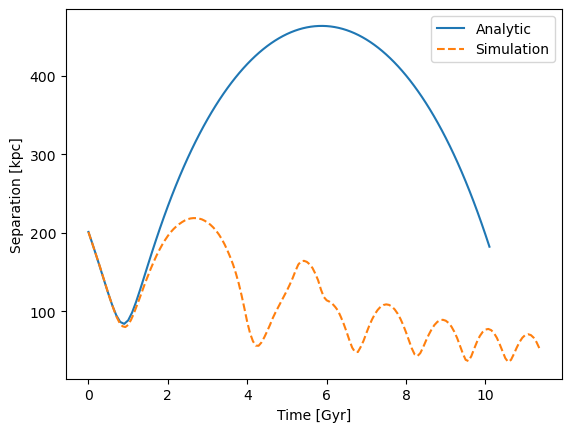

In [18]:
# Plot analytic orbital separation of M31-M33 alongside orbital separation in the simulation
plt.plot(AnalyticOrbit[:,0], np.linalg.norm(AnalyticOrbit[:,1:4], axis=1), label='Analytic')
plt.plot(M33SimOrbit[:,0] , M31_M33_Sep, linestyle='--', label='Simulation')
plt.legend()
plt.xlabel('Time [Gyr]')
plt.ylabel('Separation [kpc]')
plt.savefig('M31-M33Orbit_Comparison.png')

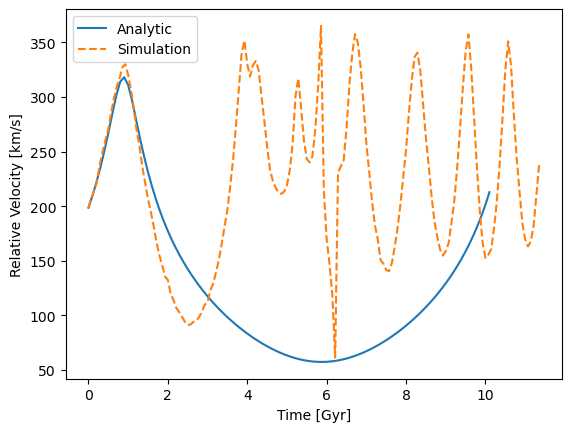

In [23]:
# Plot analytic relative velocity of M31-M33 alongside relative velocity from the simulation
plt.plot(AnalyticOrbit[:,0], np.linalg.norm(AnalyticOrbit[:,4:], axis=1), label='Analytic')
plt.plot(M33SimOrbit[:,0] , M31_M33_Vel, linestyle='--', label='Simulation')
plt.legend()
plt.xlabel('Time [Gyr]')
plt.ylabel('Relative Velocity [km/s]')
plt.savefig('M31-M33Velocity_Comparison.png')

2. How do the plots compare?

The two curves are approximately identical up until 1 Gyr, after which the analytic orbit predicts M33 will be much further away and reach an apocenter distance above 400 kpc before moving back towards M31. The simualtion, however, says that M33 will remain closeby to M31 and actually oscillate in separation over time, with some factor of damping. The simulation also predicts M33 to be moving faster than the analytic estimate.

3. What missing physics could make a difference?

This calculation assumes that the potential of M31 is constant (it is calculated at t = 0 Gyr), whereas in the simulation matter is allowed to be redistributed and moved around. Since M33 orbits M31 more closely in the simulation, the acceleration on M33 become stronger past t = 0 Gyr. This could be because M33 is losing mass and/or M31 is gaining mass such as through tidal disruptions, which is certainly true once the MW begins merging with M31.

4. The MW is missing in these calculations. How might you include its effects?

In a new relative coordinate system with the MW, I would repeat the same calculation of the total acceleration created by M31 for the MW, accounting for the acceleration created by each of the MW's mass components. I would then add this together with the acceleration contributions from M31 to calculate the total acceleration on M33. The leap frog integration can be kept as is but using this new acceleration calculation. 